### Task 3: O Orquestrador (Jupyter Notebook Refatorado)

**Step 1: O Notebook Limpo - Imports, Configs e Datasets**

In [1]:
"""
Notebook 07: Entity Embeddings, ResNet Tabular e K-Fold Anti-Overfitting
Clean Architecture: Notebook atuando como camada de orquestração e apresentação (MLflow/Optuna).
"""
import os
import sys
import numpy as np
import pandas as pd
import torch
import optuna
import mlflow
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from torch.utils.data import DataLoader

sys.path.append(os.path.abspath(os.path.join('..')))

# Importando do pacote `src` (Clean Code)
from src.ml_telco_churn.config import CONFIG
from src.features.build_features import engineer_advanced_features
from src.features.preprocessing import build_ordinal_preprocessor, build_ohe_preprocessor
from src.data.datasets import ChurnEmbeddingDataset
from src.models.tabular_resnet import AdvancedChurnMLP, FocalLoss
from src.models.train_model import train_advanced_model

# Constantes locais
RANDOM_STATE = CONFIG.random_state
TEST_SIZE = 0.2
BATCH_SIZE = 256
N_EPOCHS = 150
PATIENCE = 15
N_TRIALS_OPTUNA = 15
N_SPLITS = 3
EXPERIMENT_NAME = "05_PyTorch_ResNet_Embeddings"

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# 1. Carregamento e Feature Engineering
df_cust = pd.read_csv('../notebooks/data/raw/churn_customers.csv')
df_serv = pd.read_csv('../notebooks/data/raw/churn_services.csv')
df_cont = pd.read_csv('../notebooks/data/raw/churn_contracts.csv')

df_raw = df_cust.merge(df_serv, on='customerID').merge(df_cont, on='customerID')
df_raw = df_raw.rename(columns={'customerID': 'CustomerID', 'tenure': 'Tenure', 'gender': 'Gender'})
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
df_raw['Churn'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})

df_feat = engineer_advanced_features(df_raw)

target_col = 'Churn'
X = df_feat.drop(columns=[target_col])
y = df_feat[target_col]

num_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Holdout Cego
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

preprocessor_base = build_ordinal_preprocessor(num_cols, cat_cols)
num_features_idx = len(num_cols)

/Users/eduardobatista/Code/ML_TELCO_CHURN/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Step 2: Optuna K-Fold Objective no Notebook**

In [2]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment(EXPERIMENT_NAME)

def objective_kfold(trial):
    # Pruning no Espaço de Busca (Anti-Overfitting)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64])
    num_blocks = trial.suggest_int("num_blocks", 1, 2)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    noise_sigma = trial.suggest_float("noise_sigma", 0.01, 0.1)

    focal_gamma = trial.suggest_float("focal_gamma", 0.0, 5.0)
    focal_alpha = trial.suggest_float("focal_alpha", 0.1, 0.9)
    max_lr = trial.suggest_float("max_lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 5e-3, log=True)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    X_train_np = X_train.values
    y_train_np = y_train.values.astype(np.float32)

    for train_idx, val_idx in skf.split(X_train_np, y_train_np):
        X_fold_tr_raw = pd.DataFrame(X_train_np[train_idx], columns=X.columns)
        X_fold_val_raw = pd.DataFrame(X_train_np[val_idx], columns=X.columns)
        y_fold_tr = y_train_np[train_idx]
        y_fold_val = y_train_np[val_idx]

        prep_fold = clone(preprocessor_base)
        X_tr_proc = prep_fold.fit_transform(X_fold_tr_raw)
        X_val_proc = prep_fold.transform(X_fold_val_raw)

        cardinalities = [len(prep_fold.transformers_[1][1].named_steps['ordinal'].categories_[i]) + 2 for i in range(len(cat_cols))]

        ds_tr = ChurnEmbeddingDataset(X_tr_proc, y_fold_tr, num_features_idx)
        ds_val = ChurnEmbeddingDataset(X_val_proc, y_fold_val, num_features_idx)
        ld_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)

        model = AdvancedChurnMLP(num_features_idx, cardinalities, hidden_dim, num_blocks, dropout_rate, noise_sigma).to(device)
        criterion = FocalLoss(alpha=focal_alpha, gamma=focal_gamma).to(device)

        _, fold_auc = train_advanced_model(
            model, criterion, ld_tr, ds_val, device,
            focal_gamma, focal_alpha, max_lr, weight_decay, N_EPOCHS, PATIENCE
        )
        fold_scores.append(fold_auc)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize", study_name="resnet_kfold_tuning")
study.optimize(objective_kfold, n_trials=N_TRIALS_OPTUNA)
print(f"Melhor PR-AUC Médio no K-Fold: {study.best_value:.4f}")

[I 2026-04-25 21:42:51,510] A new study created in memory with name: resnet_kfold_tuning


[I 2026-04-25 21:43:05,603] Trial 0 finished with value: 0.6601175165634224 and parameters: {'hidden_dim': 64, 'num_blocks': 1, 'dropout_rate': 0.4832370023858525, 'noise_sigma': 0.02077821811855012, 'focal_gamma': 0.7070841388054966, 'focal_alpha': 0.7990483512304504, 'max_lr': 0.00043661073871614314, 'weight_decay': 0.00020289628249411037}. Best is trial 0 with value: 0.6601175165634224.


[I 2026-04-25 21:43:18,607] Trial 1 finished with value: 0.6570249092697931 and parameters: {'hidden_dim': 64, 'num_blocks': 1, 'dropout_rate': 0.3370983630660536, 'noise_sigma': 0.07189643871268427, 'focal_gamma': 1.4342949852699671, 'focal_alpha': 0.7743471195968019, 'max_lr': 0.00023754819014232498, 'weight_decay': 0.00022451186964861402}. Best is trial 0 with value: 0.6601175165634224.


[I 2026-04-25 21:43:32,371] Trial 2 finished with value: 0.6597759454521261 and parameters: {'hidden_dim': 64, 'num_blocks': 2, 'dropout_rate': 0.42242897114669437, 'noise_sigma': 0.025689226738131166, 'focal_gamma': 3.167507161451341, 'focal_alpha': 0.14710682712957573, 'max_lr': 0.0005638639718240027, 'weight_decay': 0.0011505403135975984}. Best is trial 0 with value: 0.6601175165634224.


[I 2026-04-25 21:43:46,266] Trial 3 finished with value: 0.6556214564960373 and parameters: {'hidden_dim': 64, 'num_blocks': 2, 'dropout_rate': 0.4734238608972412, 'noise_sigma': 0.07100451692823274, 'focal_gamma': 2.918612924779083, 'focal_alpha': 0.8311386345681083, 'max_lr': 0.00044198230341337087, 'weight_decay': 0.001206676428277757}. Best is trial 0 with value: 0.6601175165634224.


...

[I 2026-04-25 21:45:09,735] Trial 11 finished with value: 0.6507014497601007 and parameters: {'hidden_dim': 32, 'num_blocks': 2, 'dropout_rate': 0.3910669030382061, 'noise_sigma': 0.014488196621167255, 'focal_gamma': 0.11934920213788747, 'focal_alpha': 0.6590535165973914, 'max_lr': 0.001495265809376988, 'weight_decay': 0.00011015601032565565}. Best is trial 8 with value: 0.664123644403193.


[I 2026-04-25 21:45:17,741] Trial 12 finished with value: 0.658608403167671 and parameters: {'hidden_dim': 32, 'num_blocks': 1, 'dropout_rate': 0.4963914614350892, 'noise_sigma': 0.09925387384436665, 'focal_gamma': 1.4951970602644293, 'focal_alpha': 0.4585625651022801, 'max_lr': 0.0013457165805040232, 'weight_decay': 0.00046480460409440333}. Best is trial 8 with value: 0.664123644403193.


[I 2026-04-25 21:45:42,054] Trial 13 finished with value: 0.6492597033417922 and parameters: {'hidden_dim': 32, 'num_blocks': 2, 'dropout_rate': 0.3608294642145395, 'noise_sigma': 0.042869023662595686, 'focal_gamma': 1.9045981169261461, 'focal_alpha': 0.7040317687638475, 'max_lr': 0.00010739239848299373, 'weight_decay': 0.0001028388933989323}. Best is trial 8 with value: 0.664123644403193.


[I 2026-04-25 21:45:57,286] Trial 14 finished with value: 0.6540634704388179 and parameters: {'hidden_dim': 32, 'num_blocks': 1, 'dropout_rate': 0.33657796840933174, 'noise_sigma': 0.010490923708291279, 'focal_gamma': 0.7142385620711771, 'focal_alpha': 0.4922229203743115, 'max_lr': 0.000317527164765733, 'weight_decay': 0.00018216393606838486}. Best is trial 8 with value: 0.664123644403193.


Melhor PR-AUC Médio no K-Fold: 0.6641


**Step 3: Avaliação Final, Logging MLOps e Gráficos de Comparação**

2026/04/25 21:46:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/25 21:46:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/25 21:46:03 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Test PR-AUC Vencedor ResNet K-Fold: 0.6450


2026/04/25 21:46:05 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


LogReg Baseline Test PR-AUC: 0.6530


Registered model 'MLP_ResNet_Embeddings' already exists. Creating a new version of this model...
Created version '7' of model 'MLP_ResNet_Embeddings'.
/Users/eduardobatista/Code/ML_TELCO_CHURN/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


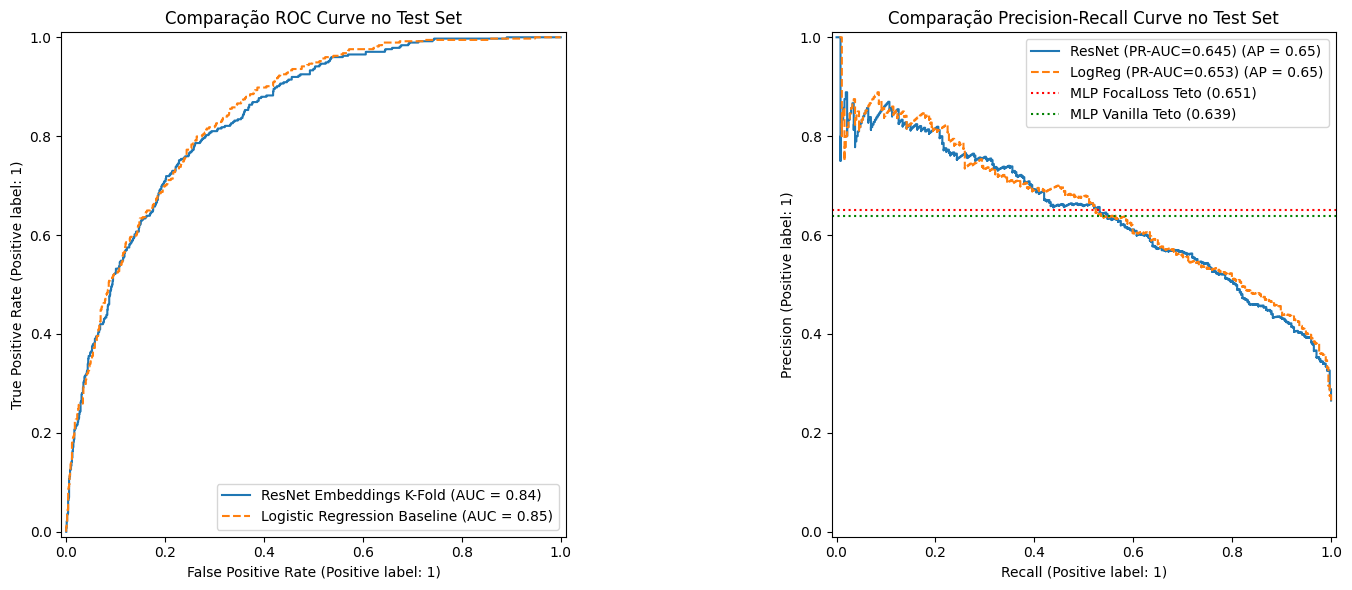

In [3]:
best = study.best_params

from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# Retreino em 100% da base de treino
final_preprocessor = clone(preprocessor_base)
X_tr_final_proc = final_preprocessor.fit_transform(X_train)
X_test_final_proc = final_preprocessor.transform(X_test)

final_cards = [len(final_preprocessor.transformers_[1][1].named_steps['ordinal'].categories_[i]) + 2 for i in range(len(cat_cols))]

ds_tr_final = ChurnEmbeddingDataset(X_tr_final_proc, y_train.values, num_features_idx)
ld_tr_final = DataLoader(ds_tr_final, batch_size=BATCH_SIZE, shuffle=True)
ds_test_final = ChurnEmbeddingDataset(X_test_final_proc, y_test.values, num_features_idx)

final_model = AdvancedChurnMLP(num_features_idx, final_cards, best["hidden_dim"], best["num_blocks"], best["dropout_rate"], best["noise_sigma"]).to(device)
final_criterion = FocalLoss(alpha=best["focal_alpha"], gamma=best["focal_gamma"]).to(device)

final_model, _ = train_advanced_model(
    final_model, final_criterion, ld_tr_final, ds_test_final, device,
    best["focal_gamma"], best["focal_alpha"], best["max_lr"], best["weight_decay"], N_EPOCHS, PATIENCE
)

final_model.eval()
with torch.no_grad():
    X_num_test, X_cat_test = ds_test_final.X_num.to(device), ds_test_final.X_cat.to(device)
    test_probs = torch.sigmoid(final_model(X_num_test, X_cat_test)).cpu().numpy()
    test_pr_auc = average_precision_score(ds_test_final.y.numpy(), test_probs)
    test_preds = (test_probs >= 0.5).astype(int)
    test_roc_auc = roc_auc_score(ds_test_final.y.numpy(), test_probs)
    test_f1 = f1_score(ds_test_final.y.numpy(), test_preds)
    test_precision = precision_score(ds_test_final.y.numpy(), test_preds, zero_division=0)
    test_recall = recall_score(ds_test_final.y.numpy(), test_preds)

print(f"Test PR-AUC Vencedor ResNet K-Fold: {test_pr_auc:.4f}")

# MLflow Logging com Pipeline Salvo!
with mlflow.start_run(run_name="MLP_ResNet_KFold"):
    mlflow.log_params(best)
    mlflow.log_metrics({
        "test_pr_auc": test_pr_auc,
        "test_roc_auc": test_roc_auc,
        "test_f1": test_f1,
        "test_precision": test_precision,
        "test_recall": test_recall
    })

    # 1. Logar o preprocessor exigido pela Governança para o FastAPI
    mlflow.sklearn.log_model(final_preprocessor, "preprocessor")

    final_model.cpu()
    sample_num = ds_test_final.X_num[:1].numpy().astype(np.float32)
    sample_cat = ds_test_final.X_cat[:1].numpy().astype(np.int64)
    out_sig = final_model(torch.tensor(sample_num), torch.tensor(sample_cat)).detach().numpy()

    from mlflow.models.signature import infer_signature
    sig = infer_signature({"x_num": sample_num, "x_cat": sample_cat}, out_sig)

    mlflow.pytorch.log_model(
        final_model,
        name="model",
        registered_model_name="MLP_ResNet_Embeddings",
        signature=sig
    )

# --- Comparação Baseline e Gráficos ---
lr_preprocessor = build_ohe_preprocessor(num_cols, cat_cols)
X_tr_lr = lr_preprocessor.fit_transform(X_train)
X_test_lr = lr_preprocessor.transform(X_test)

lr_model = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_tr_lr, y_train)
lr_probs = lr_model.predict_proba(X_test_lr)[:, 1]
lr_pr_auc = average_precision_score(y_test, lr_probs)

# Histórico das MLPs Anteriores
mlp_adv_loss_pr = 0.6512
mlp_vanilla_pr = 0.6392

print(f"LogReg Baseline Test PR-AUC: {lr_pr_auc:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

RocCurveDisplay.from_predictions(y_test, test_probs, name="ResNet Embeddings K-Fold", ax=ax[0])
RocCurveDisplay.from_predictions(y_test, lr_probs, name="Logistic Regression Baseline", ax=ax[0], linestyle="--")
ax[0].set_title("Comparação ROC Curve no Test Set")

PrecisionRecallDisplay.from_predictions(y_test, test_probs, name=f"ResNet (PR-AUC={test_pr_auc:.3f})", ax=ax[1])
PrecisionRecallDisplay.from_predictions(y_test, lr_probs, name=f"LogReg (PR-AUC={lr_pr_auc:.3f})", ax=ax[1], linestyle="--")
ax[1].axhline(y=mlp_adv_loss_pr, color='r', linestyle=':', label=f"MLP FocalLoss Teto ({mlp_adv_loss_pr:.3f})")
ax[1].axhline(y=mlp_vanilla_pr, color='g', linestyle=':', label=f"MLP Vanilla Teto ({mlp_vanilla_pr:.3f})")
ax[1].legend()
ax[1].set_title("Comparação Precision-Recall Curve no Test Set")

plt.tight_layout()
plt.show()

with mlflow.start_run(run_name="MLP_ResNet_KFold", nested=True) as run:
    fig.savefig("resnet_comparison.png")
    mlflow.log_artifact("resnet_comparison.png")